<Figure size 1440x864 with 0 Axes>

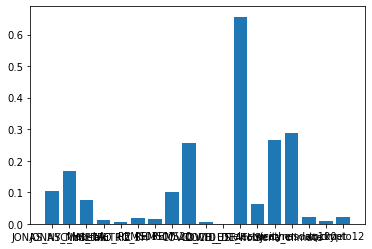

In [ ]:
from tasks.data_analysis import DataAnalysis
import matplotlib.pyplot as plt
import numpy as np
import json

root_path = '/home/ysc/workspace/Tensor-Time-Series/datasets/data/'
# pkl_path = root_path + "JONAS_NYC_bike/JONAS_NYC_bike.pkl"
# pkl_path = root_path + 'JONAS_NYC_taxi/JONAS_NYC_taxi.pkl'
# pkl_path = root_path + 'PEMS04/PEMS04.pkl'
# pkl_path = root_path + 'METRO_SH/METRO_SH.pkl'
Datasets =  ['JONAS_NYC_bike', 'JONAS_NYC_taxi', 'Metr-LA','METRO_HZ', 'METRO_SH','PEMS03', 'PEMS07', 'PEMS20', 'COVID_CHI', 'COVID_US',
                'COVID_DEATHS',
                'ETT_hour','electricity',
                'weather', 'Jena_climate',
                'nasdaq100', 'stocknet','crypto12']

# pkl_path = root_path + 'weather/weather.pkl'
dataset_res = {}
# pkl_path = '/home/ysc/workspace/Tensor-Time-Series/datasets/Tensor-Time-Series-Dataset/Processed_Data/Metr-LA/Metr-LA.pkl'
for dastaset in Datasets:
    pkl_path = root_path + f'{dastaset}/{dastaset}.pkl'
    data_analysis = DataAnalysis(pkl_path)
    data_analysis.normalize()
    data = data_analysis.data
    varients_num = data.shape[1]
    reduced_num = max(int(0.2*varients_num),2)
    best_n_components, error = data_analysis.find_best_n_components(data= data, max_components= reduced_num)
    # error = data_analysis.pca_reconstruction_error(data= data, n_components= reduced_num)
    dataset_res[dastaset] = error
with open('dataset_res.json', 'w') as f:
    json.dump(dataset_res, f)
    f.close()
visual_res = {}
for key, value in dataset_res.items():
    visual_res[key] = value[-1]
#draw bar chart
plt.figure(figsize=(20, 12))
fig, ax = plt.subplots()
keys = list(visual_res.keys())
values = list(visual_res.values())
ax.bar(keys, values)
plt.show()


    # shift_factor = 12*24
    # source = np.average(data[:,:10], axis = 1)
    # # shift_factors = [1, 6, 12, 24, 36, 72, 144, 12*24, 12*30, 12*36, 12*48, 12*60, 12*72, 12*84, 12*96, 12*108, 12*120, 12*132, 12*144]
    # shift_factors = [i*18 for i in range(1, 20)]
    # # shift_factors = [1, 4, 12, 24, 36, 72, 4*24, 144]
    # errors = []
    # for shift_factor in shift_factors:
    #     constructed = []
    #     for i in range(10):
    #         constructed.append(np.roll(source, i*shift_factor))
    #     constructed = np.array(constructed).T
    #     best_n_components, error = data_analysis.find_best_n_components(data = constructed, max_components = 10)
    #     errors.append(error[2])
    # plt.plot(shift_factors, errors, marker = 'o')
    # data_analysis.plot_reconstruction_errors(error)
# best_n_components, error = data_analysis.find_best_n_components(data = data[:,:10], max_components = 10)
# data_analysis.plot_reconstruction_errors(error)


# print(constructed)
# sim_eval_1 = data_analysis.eval_tensor(axis = 1,method = 'corelation')
# sim_eval_2 = data_analysis.eval_tensor(axis = 2,method = 'corelation')

# plt.figure(figsize = (10, 5))
# plt.subplot(121)
# plt.imshow(sim_eval_1, cmap='hot', interpolation='nearest')
# plt.title('Similarity Evaluation by axis 1')
# # plt.figtext(0.5, 0.01, f'mean:{np.mean(sim_eval_1):.2f},std:{np.std(sim_eval_1):.2f}', wrap=True, horizontalalignment='center', fontsize=12)
# plt.colorbar()
# plt.subplot(122)
# plt.imshow(sim_eval_2, cmap='hot', interpolation='nearest')
# plt.title('Similarity Evaluation by axis 2')
# plt.figtext(0.5, 0.01, f'mean:{np.mean(sim_eval_1):.2f},std:{np.std(sim_eval_1):.2f}, mean:{np.mean(sim_eval_2):.2f},std:{np.std(sim_eval_2):.2f}', wrap=True, horizontalalignment='center', fontsize=12)
# plt.colorbar()
# plt.show()

# periods = data_analysis.find_periods(k = 5)
# for period in periods:
#     print(period)

# pe = data_analysis.tensor_permutation_entropy(embedding = 5, time_delay = 12)
# print(f"permutation entropy {pe}")

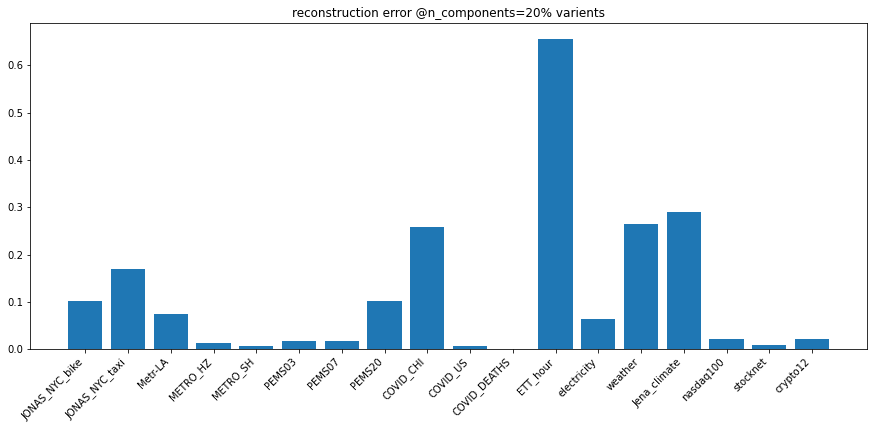

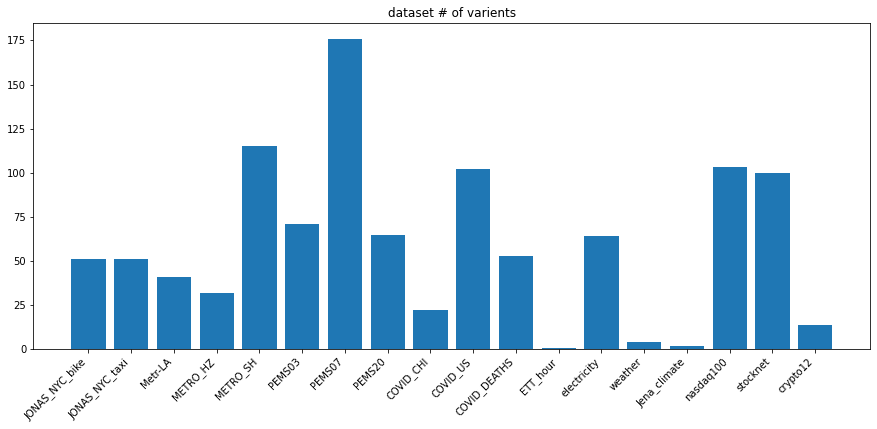

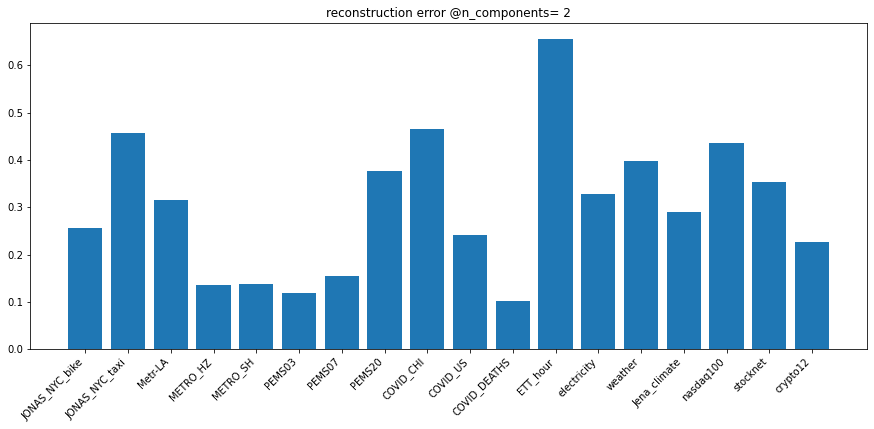

In [11]:
with open('dataset_res.json', 'r') as f:
    dataset_res = json.load(f)
    f.close()
visual_res = {}
dataset_size = {}
rec_error = {}
component = 2
for key, value in dataset_res.items():
    visual_res[key] = value[-1]
    dataset_size[key] = len(value)
    rec_error[key] = value[min(component-1, len(value)-1)]
#draw bar chart


fig, ax = plt.subplots(figsize=(15, 6))
keys = list(visual_res.keys())
values = list(visual_res.values())
ax.bar(keys,values)
plt.xticks(rotation = 45, ha = 'right')
plt.title('reconstruction error @n_components=20% varients')
plt.show()


fig, ax = plt.subplots(figsize=(15, 6))
keys = list(dataset_size.keys())
values = list(dataset_size.values())
ax.bar(keys,values)
plt.xticks(rotation = 45, ha = 'right')
plt.title('dataset # of varients')
plt.show()

fig, ax = plt.subplots(figsize=(15, 6))
keys = list(rec_error.keys())
values = list(rec_error.values())
ax.bar(keys,values)
plt.xticks(rotation = 45, ha = 'right')
plt.title(f'reconstruction error @n_components= {component}')
plt.show()




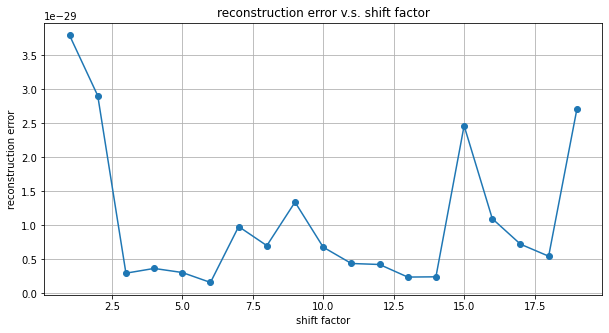

In [6]:
from tasks.data_analysis import DataAnalysis
import matplotlib.pyplot as plt
import numpy as np
import json

root_path = '/home/ysc/workspace/Tensor-Time-Series/datasets/data/'
# pkl_path = root_path + "JONAS_NYC_bike/JONAS_NYC_bike.pkl"
# pkl_path = root_path + 'JONAS_NYC_taxi/JONAS_NYC_taxi.pkl'
pkl_path = root_path + 'PEMS04/PEMS04.pkl'
# pkl_path = root_path + 'METRO_SH/METRO_SH.pkl
   # shift_factor = 12*24
data_analysis = DataAnalysis(pkl_path)
data_analysis.normalize()
data = data_analysis.data
varients_num = data.shape[1]
reduced_num = int(0.2*varients_num)
source = np.average(data, axis = 1)
# shift_factors = [1, 6, 12, 24, 36, 72, 144, 12*24, 12*30, 12*36, 12*48, 12*60, 12*72, 12*84, 12*96, 12*108, 12*120, 12*132, 12*144]
shift_factors = [i for i in range(1, 20)]
shift_base = 12
# shift_factors = [1, 4, 12, 24, 36, 72, 4*24, 144]
errors = []
for shift_factor in shift_factors:
    constructed = []
    for i in range(reduced_num):
        constructed.append(np.roll(source, i*shift_factor*shift_base))
    constructed = np.array(constructed).T
    error = data_analysis.pca_reconstruction_error(data = constructed, n_components = reduced_num)
    errors.append(error)
    # best_n_components, error = data_analysis.find_best_n_components(data = constructed, max_components = 10)
    # errors.append(error[2])
ori_error= data_analysis.pca_reconstruction_error(data = data, n_components = reduced_num)
plt.figure(figsize = (10, 5))
plt.plot(shift_factors, errors, marker = 'o')
# plt.axhline(y=ori_error, color='r', linestyle='--', linewidth=2)
plt.xlabel('shift factor')
plt.ylabel('reconstruction error')
plt.grid(True)
plt.title('reconstruction error v.s. shift factor')
plt.show()
# data_analysis.plot_reconstruction_errors(error)
# best_n_components, error = data_analysis.find_best_n_components(data = data[:,:10], max_components = 10)
# data_analysis.plot_reconstruction_errors(error)


--------------------
varients_num:307, reduced_dim:61


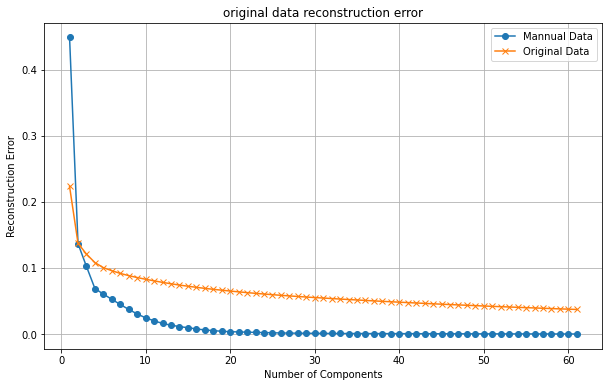

In [2]:
from tasks.data_analysis import DataAnalysis
import matplotlib.pyplot as plt
import numpy as np
import json

root_path = '/home/ysc/workspace/Tensor-Time-Series/datasets/data/'
# pkl_path = root_path + "JONAS_NYC_bike/JONAS_NYC_bike.pkl"
# pkl_path = root_path + 'JONAS_NYC_taxi/JONAS_NYC_taxi.pkl'
pkl_path = root_path + 'PEMS04/PEMS04.pkl'
# pkl_path = root_path + 'METRO_SH/METRO_SH.pkl
   # shift_factor = 12*24
data_analysis = DataAnalysis(pkl_path)
data_analysis.normalize()
data = data_analysis.data
varients_num = data.shape[1]
reduced_num = int(0.2*varients_num)
print('-'*20)
print(f'varients_num:{varients_num}, reduced_dim:{reduced_num}')
source = np.average(data, axis = 1)
# shift_factors = [1, 6, 12, 24, 36, 72, 144, 12*24, 12*30, 12*36, 12*48, 12*60, 12*72, 12*84, 12*96, 12*108, 12*120, 12*132, 12*144]
# shift_factors = [i for i in range(1, 20)]
shift_factor = 1
shift_base = 12
# shift_factors = [1, 4, 12, 24, 36, 72, 4*24, 144]
errors = []
# for shift_factor in shift_factors:
constructed = []
for i in range(reduced_num):
    constructed.append(np.roll(source, i*shift_factor*shift_base))
constructed = np.array(constructed).T
best_n_components, error = data_analysis.find_best_n_components(data = constructed, max_components = reduced_num)
# data_analysis.plot_reconstruction_errors(error, title = 'manual data reconstruction error')
best_n_components, error2 = data_analysis.find_best_n_components(data = data, max_components = reduced_num)
data_analysis.plot_reconstruction_errors(error, title = 'original data reconstruction error',errors2 = error2)
# error = data_analysis.pca_reconstruction_error(data = constructed, n_components = reduced_num)

# errors.append(error)
    # best_n_components, error = data_analysis.find_best_n_components(data = constructed, max_components = 10)
    # errors.append(error[2])
# plt.plot(shift_factors, errors, marker = 'o')